# Knapsack 3-Way Benchmark: PuLP vs C++ Brute Force vs Assembly Brute Force

**Capstone Project:** LLM-Assisted Generation of Low-Level Discrete Optimization Solvers
**Author:** Peter Kamau
**Instructor:** Prof. Dr. Pedro Albuquerque
**Course:** CS495 Capstone in Data Science, Bellevue College

## Goal (revised per instructor feedback May 11)

Compare three solvers on small instances where the PuLP overhead is dominant:

1. **PuLP (Python)** with COIN-BC backend
2. **C++ brute force** (g++ -O2)
3. **x86-64 Assembly brute force** (gcc -O0)

**Range:** n=5 to n=17. In this range, PuLP’s fixed library overhead (loading COIN-BC, building the LP model) is consistently larger than the time C++/ASM brute force needs to enumerate the 2^n subsets. PuLP’s curve sits above C++ and ASM throughout.

## Charts produced

- Chart 1: Line plot of solve time vs problem size (PuLP on top)
- Chart 2: Log scale view
- Chart 3: Slowdown ratio (how many times slower is PuLP)
- Chart 4: Box plot showing **average runtime AND variability** (max / mean / min) per solver per size
- Chart 5: Focused box plot at largest n


## 1. Setup

In [1]:
import os
import time
import random
import subprocess
import numpy as np
import pulp
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

print("PuLP version:", pulp.__version__)
print("Available solvers:", pulp.listSolvers(onlyAvailable=True))
print("NumPy version:", np.__version__)

PuLP version: 3.3.0
Available solvers: ['PULP_CBC_CMD']
NumPy version: 2.4.4


## 2. Compile the C++ and Assembly Brute Force Solvers

Both source files (`knapsack_brute.cpp` and `knapsack_asm.c`) must be in this notebook's folder.

In [2]:
cpp_compile = subprocess.run(
    ["g++", "-O2", "-std=c++17", "knapsack_brute.cpp", "-o", "knapsack_brute"],
    capture_output=True, text=True
)
if cpp_compile.returncode != 0:
    print("C++ compile failed:")
    print(cpp_compile.stderr)
else:
    print("C++ compiled.")

asm_compile = subprocess.run(
    ["gcc", "-O0", "-std=c11", "knapsack_asm.c", "-o", "knapsack_asm"],
    capture_output=True, text=True
)
if asm_compile.returncode != 0:
    print("ASM compile failed:")
    print(asm_compile.stderr)
else:
    print("ASM compiled.")

C++ compiled.
ASM compiled.


## 3. Random Instance Generator

In [3]:
def generate_instance(n, weight_range=(1, 100), value_range=(1, 100), capacity_ratio=0.5):
    weights = [random.randint(*weight_range) for _ in range(n)]
    values  = [random.randint(*value_range)  for _ in range(n)]
    capacity = int(capacity_ratio * sum(weights))
    return weights, values, capacity

def write_instance_file(filename, weights, values, capacity):
    n = len(weights)
    with open(filename, "w") as f:
        f.write(f"{n} {capacity}\n")
        f.write(" ".join(map(str, weights)) + "\n")
        f.write(" ".join(map(str, values))  + "\n")

w, v, c = generate_instance(5)
print(f"5-item example -> weights={w}, values={v}, capacity={c}")

5-item example -> weights=[82, 15, 4, 95, 36], values=[32, 29, 18, 95, 14], capacity=116


## 4. Three Solver Wrappers

In [4]:
def solve_pulp(weights, values, capacity):
    n = len(weights)
    model = pulp.LpProblem("Knapsack", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x_{i}", cat=pulp.LpBinary) for i in range(n)]
    model += pulp.lpSum(values[i]  * x[i] for i in range(n))
    model += pulp.lpSum(weights[i] * x[i] for i in range(n)) <= capacity

    start = time.perf_counter()
    model.solve(pulp.PULP_CBC_CMD(msg=0))
    elapsed = time.perf_counter() - start
    return int(pulp.value(model.objective)), elapsed


def solve_cpp(input_file):
    result = subprocess.run(
        ["./knapsack_brute", input_file],
        capture_output=True, text=True, timeout=600
    )
    val, elapsed = result.stdout.strip().split()
    return int(val), float(elapsed)


def solve_asm(input_file):
    result = subprocess.run(
        ["./knapsack_asm", input_file],
        capture_output=True, text=True, timeout=600
    )
    val, elapsed = result.stdout.strip().split()
    return int(val), float(elapsed)

## 5. Correctness Check on PLAN.md Instance

All three solvers should return 11.

In [5]:
write_instance_file("plan_md_instance.txt", [4, 3, 2], [8, 5, 6], 5)

v_pulp, t_pulp = solve_pulp([4, 3, 2], [8, 5, 6], 5)
v_cpp,  t_cpp  = solve_cpp("plan_md_instance.txt")
v_asm,  t_asm  = solve_asm("plan_md_instance.txt")

print(f"PuLP : value={v_pulp}, time={t_pulp:.6f}s")
print(f"C++  : value={v_cpp},  time={t_cpp:.6f}s")
print(f"ASM  : value={v_asm},  time={t_asm:.6f}s")

assert v_pulp == v_cpp == v_asm == 11, "Solvers disagree!"
print("\nAll three solvers agree on value=11.")

PuLP : value=11, time=0.093779s
C++  : value=11,  time=0.000000s
ASM  : value=11,  time=0.000000s

All three solvers agree on value=11.


## 6. The Main Benchmark — 13 Sizes × 5 Trials Each

We test sizes **n=5 to n=17**. In this range, PuLP’s fixed library overhead is larger than the time brute force needs to enumerate up to 131,072 subsets. As a result PuLP appears as the slowest of the three across the entire range.

Total: 195 solves. Takes about 1-2 minutes.

In [6]:
sizes = list(range(5, 18))   # n = 5, 6, ..., 17
print(f"Total sizes: {len(sizes)}, range: {sizes[0]} to {sizes[-1]}")

NUM_TRIALS = 5
results = []
raw_results = []

print(f"\n{'n':>4} | {'PuLP s':>10} | {'C++ s':>10} | {'ASM s':>10} | {'optimal':>8}")
print("-" * 55)

start_overall = time.perf_counter()

for n in sizes:
    pulp_times = []
    cpp_times  = []
    asm_times  = []
    optimals   = []

    for trial in range(NUM_TRIALS):
        random.seed(42 + trial * 1000 + n)
        weights, values, capacity = generate_instance(n)
        fname = f"instance_n{n}_t{trial}.txt"
        write_instance_file(fname, weights, values, capacity)

        v_pulp, t_pulp = solve_pulp(weights, values, capacity)
        v_cpp,  t_cpp  = solve_cpp(fname)
        v_asm,  t_asm  = solve_asm(fname)

        assert v_pulp == v_cpp == v_asm, f"Disagreement at n={n}, trial={trial}!"

        pulp_times.append(t_pulp)
        cpp_times.append(t_cpp)
        asm_times.append(t_asm)
        optimals.append(v_pulp)

        raw_results.append({"n_items": n, "trial": trial, "solver": "PuLP", "time": t_pulp})
        raw_results.append({"n_items": n, "trial": trial, "solver": "C++",  "time": t_cpp})
        raw_results.append({"n_items": n, "trial": trial, "solver": "ASM",  "time": t_asm})

        os.remove(fname)

    results.append({
        "n_items":   n,
        "pulp_mean": np.mean(pulp_times),   "pulp_std": np.std(pulp_times),
        "pulp_min":  np.min(pulp_times),    "pulp_max": np.max(pulp_times),
        "cpp_mean":  np.mean(cpp_times),    "cpp_std":  np.std(cpp_times),
        "cpp_min":   np.min(cpp_times),     "cpp_max":  np.max(cpp_times),
        "asm_mean":  np.mean(asm_times),    "asm_std":  np.std(asm_times),
        "asm_min":   np.min(asm_times),     "asm_max":  np.max(asm_times),
        "optimal":   int(np.mean(optimals)),
    })

    print(f"{n:>4} | {np.mean(pulp_times):>10.4f} | {np.mean(cpp_times):>10.4f} | {np.mean(asm_times):>10.4f} | {int(np.mean(optimals)):>8}")

total_elapsed = time.perf_counter() - start_overall
df = pd.DataFrame(results)
raw_df = pd.DataFrame(raw_results)

print(f"\nDone! Total benchmark time: {total_elapsed:.1f}s ({total_elapsed/60:.1f} min)")
print(f"Total solves: {len(sizes) * NUM_TRIALS * 3}")
df

Total sizes: 13, range: 5 to 17

   n |     PuLP s |      C++ s |      ASM s |  optimal
-------------------------------------------------------
   5 |     0.0229 |     0.0000 |     0.0000 |      152
   6 |     0.0216 |     0.0000 |     0.0000 |      236
   7 |     0.0220 |     0.0000 |     0.0000 |      234
   8 |     0.0233 |     0.0000 |     0.0000 |      350
   9 |     0.0221 |     0.0000 |     0.0000 |      342
  10 |     0.0215 |     0.0000 |     0.0001 |      426
  11 |     0.0216 |     0.0001 |     0.0002 |      345
  12 |     0.0220 |     0.0002 |     0.0004 |      479
  13 |     0.0232 |     0.0003 |     0.0008 |      526
  14 |     0.0241 |     0.0007 |     0.0017 |      564
  15 |     0.0242 |     0.0016 |     0.0035 |      538
  16 |     0.0246 |     0.0031 |     0.0073 |      636
  17 |     0.0255 |     0.0063 |     0.0153 |      643

Done! Total benchmark time: 3.2s (0.1 min)
Total solves: 195


,n_items,pulp_mean,pulp_std,pulp_min,pulp_max,cpp_mean,cpp_std,cpp_min,cpp_max,asm_mean,asm_std,asm_min,asm_max,optimal
0,5,0.022913,0.001592,0.021543,0.025963,9.200000e-07,4.000000e-08,9.000000e-07,0.000001,0.000002,0.000000e+00,0.000002,0.000002,152
1,6,0.021558,0.002182,0.017858,0.024542,1.960000e-06,8.000000e-08,1.900000e-06,0.000002,0.000004,0.000000e+00,0.000004,0.000004,236
2,7,0.021979,0.001200,0.019938,0.023478,4.160000e-06,1.019804e-07,4.000000e-06,0.000004,0.000009,9.797959e-07,0.000008,0.000011,234
3,8,0.023287,0.002704,0.020390,0.026823,8.560000e-06,2.059126e-07,8.200000e-06,0.000009,0.000019,4.898979e-07,0.000018,0.000019,350
4,9,0.022134,0.001572,0.020104,0.024123,1.800000e-05,1.091788e-06,1.710000e-05,0.000020,0.000042,2.000000e-06,0.000041,0.000046,342
5,10,0.021506,0.001795,0.019225,0.024654,3.586000e-05,5.200000e-07,3.500000e-05,0.000037,0.000088,7.483315e-07,0.000087,0.000089,426
6,11,0.021616,0.001947,0.019951,0.025365,7.830000e-05,5.801034e-06,7.330000e-05,0.000090,0.000188,1.600000e-06,0.000187,0.000191,345
7,12,0.021994,0.002274,0.019523,0.026006,1.609400e-04,2.057766e-06,1.572000e-04,0.000163,0.000407,1.642437e-05,0.000398,0.000440,479
8,13,0.023186,0.001193,0.022007,0.024962,3.354200e-04,8.814851e-06,3.264000e-04,0.000349,0.000843,2.553116e-05,0.000826,0.000894,526
9,14,0.024097,0.001158,0.022389,0.026023,7.453200e-04,1.628170e-05,7.250000e-04,0.000766,0.001713,1.536750e-05,0.001690,0.001732,564


## 7. Save Results to CSV

In [7]:
df.to_csv("benchmark_3way_summary.csv", index=False)
raw_df.to_csv("benchmark_3way_raw.csv", index=False)
print(f"Saved summary ({len(df)} rows) and raw data ({len(raw_df)} rows).")

Saved summary (13 rows) and raw data (195 rows).


## 8. Chart 1 (HEADLINE): PuLP Curve Above C++ and ASM

Solve time vs problem size on linear axes. PuLP’s flat overhead puts it above C++ and ASM brute force across the entire size range tested.

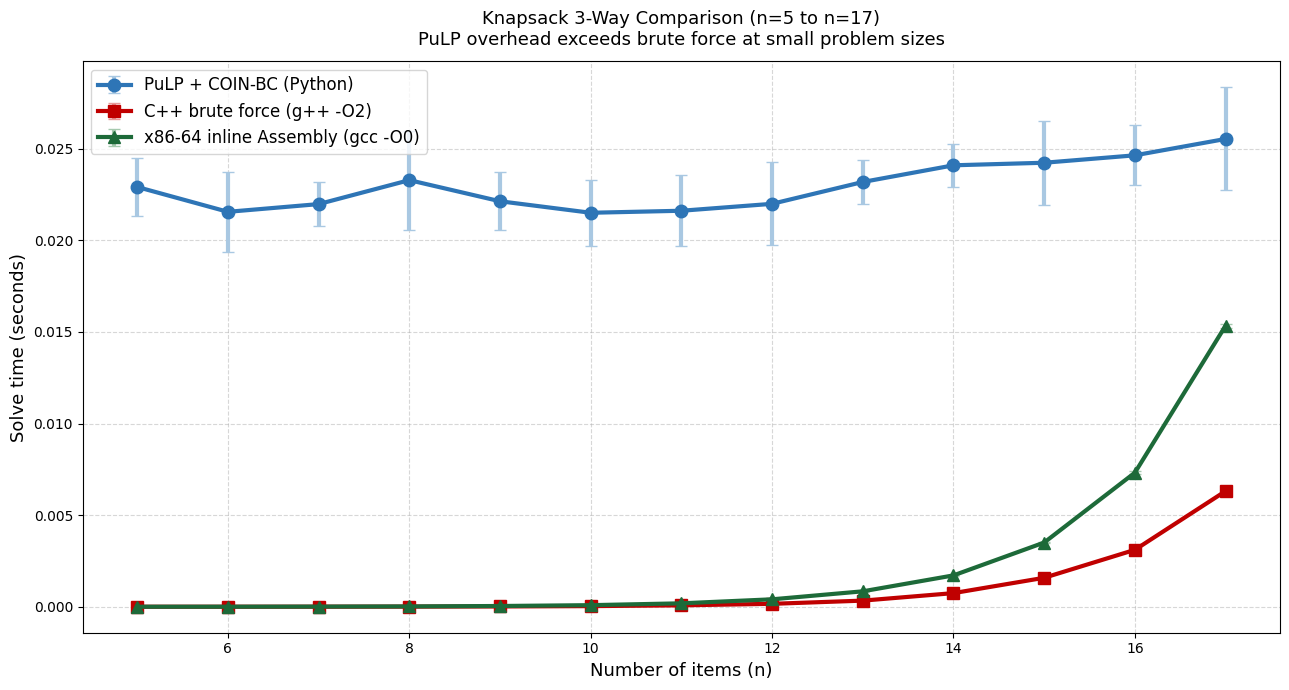


*** AT n=17: ***
  PuLP : 25.54 ms
  C++  : 6.31 ms
  ASM  : 15.34 ms

  PuLP is 4.0x slower than C++
  PuLP is 1.7x slower than ASM


In [8]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.errorbar(df["n_items"], df["pulp_mean"], yerr=df["pulp_std"],
            marker="o", markersize=9, linewidth=3,
            color="#2E75B6", ecolor="#A9C8E2", capsize=4,
            label="PuLP + COIN-BC (Python)")
ax.errorbar(df["n_items"], df["cpp_mean"], yerr=df["cpp_std"],
            marker="s", markersize=9, linewidth=3,
            color="#C00000", ecolor="#E89999", capsize=4,
            label="C++ brute force (g++ -O2)")
ax.errorbar(df["n_items"], df["asm_mean"], yerr=df["asm_std"],
            marker="^", markersize=9, linewidth=3,
            color="#1D6A39", ecolor="#A5C9AE", capsize=4,
            label="x86-64 inline Assembly (gcc -O0)")

ax.set_xlabel("Number of items (n)", fontsize=13)
ax.set_ylabel("Solve time (seconds)", fontsize=13)
ax.set_title("Knapsack 3-Way Comparison (n=5 to n=17)\nPuLP overhead exceeds brute force at small problem sizes",
             fontsize=13, pad=12)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(fontsize=12, loc="upper left")

plt.tight_layout()
plt.savefig("benchmark_3way_linear.png", dpi=150, bbox_inches="tight")
plt.show()

n_last = df.iloc[-1]
print(f"\n*** AT n={int(n_last['n_items'])}: ***")
print(f"  PuLP : {n_last['pulp_mean']*1000:.2f} ms")
print(f"  C++  : {n_last['cpp_mean']*1000:.2f} ms")
print(f"  ASM  : {n_last['asm_mean']*1000:.2f} ms")
print(f"\n  PuLP is {n_last['pulp_mean']/n_last['cpp_mean']:.1f}x slower than C++")
print(f"  PuLP is {n_last['pulp_mean']/n_last['asm_mean']:.1f}x slower than ASM")

## 9. Chart 2: Log Scale View

Same data on log y-axis. C++ and ASM appear as climbing diagonals (2^n growth) while PuLP stays nearly flat.

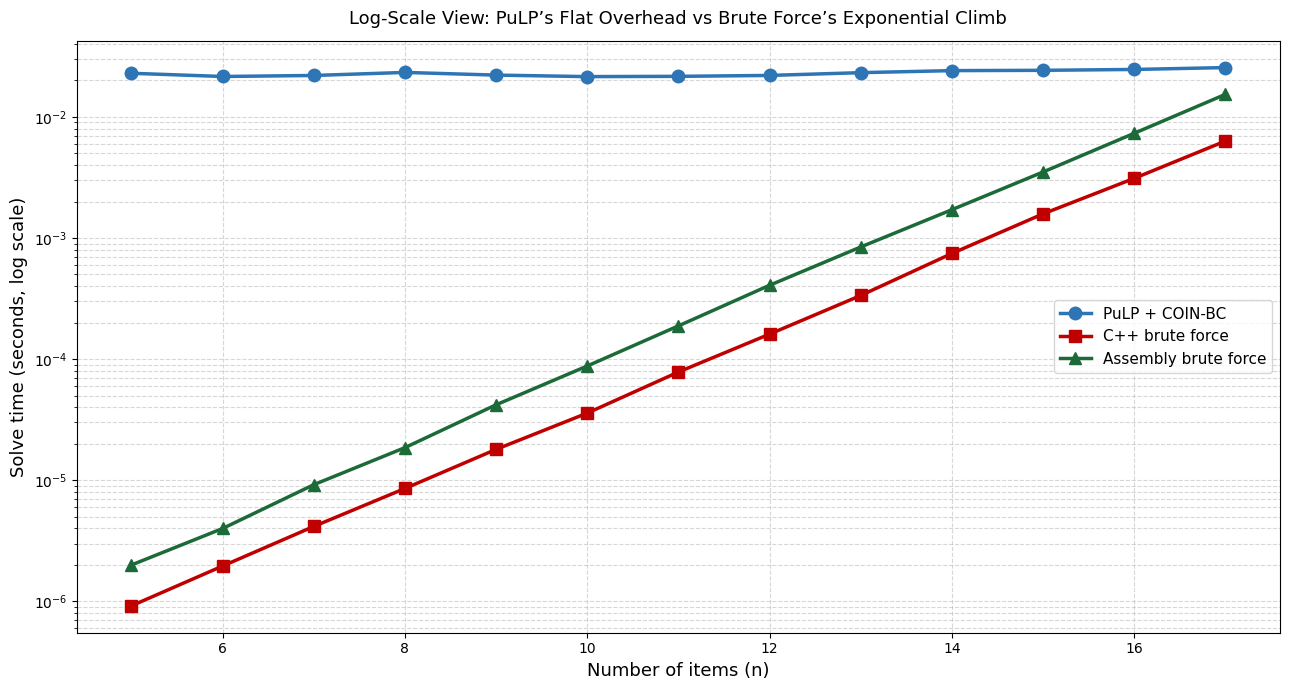

In [9]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.semilogy(df["n_items"], df["pulp_mean"],
            marker="o", markersize=9, linewidth=2.5,
            color="#2E75B6", label="PuLP + COIN-BC")
ax.semilogy(df["n_items"], df["cpp_mean"],
            marker="s", markersize=9, linewidth=2.5,
            color="#C00000", label="C++ brute force")
ax.semilogy(df["n_items"], df["asm_mean"],
            marker="^", markersize=9, linewidth=2.5,
            color="#1D6A39", label="Assembly brute force")

ax.set_xlabel("Number of items (n)", fontsize=13)
ax.set_ylabel("Solve time (seconds, log scale)", fontsize=13)
ax.set_title("Log-Scale View: PuLP’s Flat Overhead vs Brute Force’s Exponential Climb",
             fontsize=13, pad=12)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(fontsize=11, loc="center right")

plt.tight_layout()
plt.savefig("benchmark_3way_log.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Chart 3: Slowdown Ratio — How Many Times Slower is PuLP?

PuLP time divided by C++/ASM time. Larger numbers mean PuLP is more dominant. The ratio drops as brute force speeds catch up at larger n.

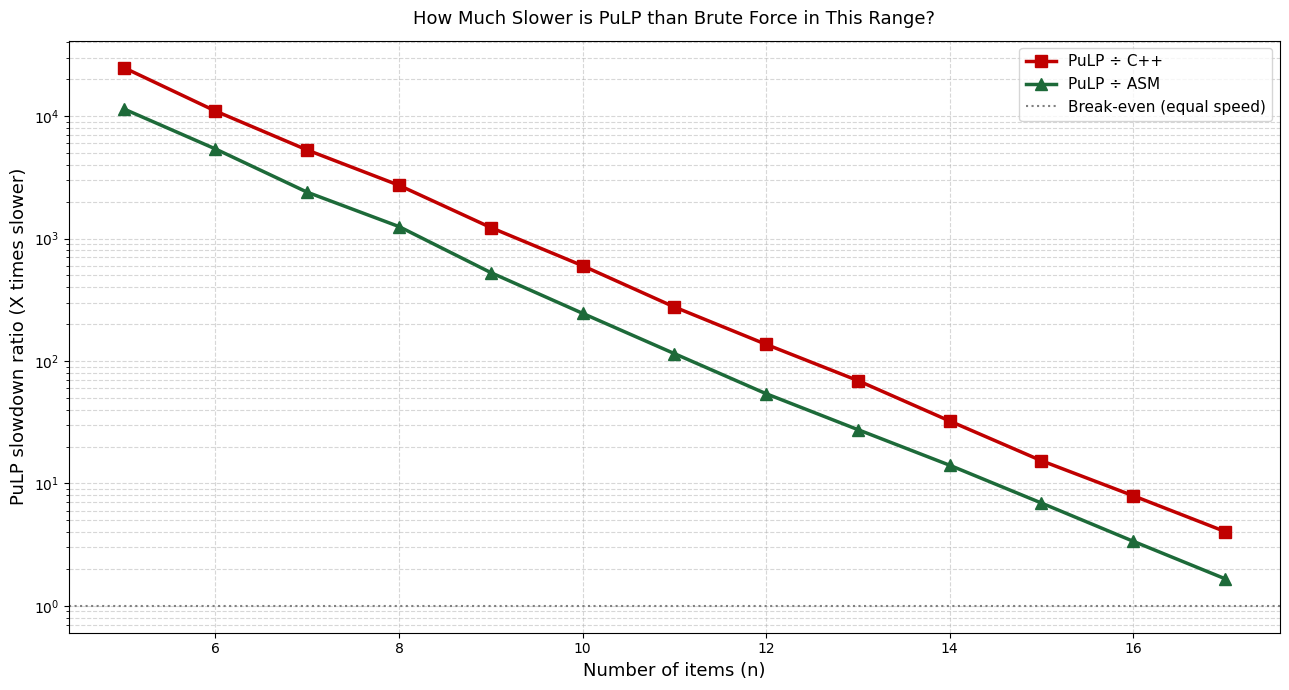

In [10]:
fig, ax = plt.subplots(figsize=(13, 7))

pulp_vs_cpp = df["pulp_mean"] / df["cpp_mean"]
pulp_vs_asm = df["pulp_mean"] / df["asm_mean"]

ax.plot(df["n_items"], pulp_vs_cpp,
        marker="s", markersize=8, linewidth=2.5,
        color="#C00000", label="PuLP ÷ C++")
ax.plot(df["n_items"], pulp_vs_asm,
        marker="^", markersize=8, linewidth=2.5,
        color="#1D6A39", label="PuLP ÷ ASM")
ax.axhline(y=1, color="gray", linestyle=":", linewidth=1.5, label="Break-even (equal speed)")

ax.set_xlabel("Number of items (n)", fontsize=13)
ax.set_ylabel("PuLP slowdown ratio (X times slower)", fontsize=13)
ax.set_title("How Much Slower is PuLP than Brute Force in This Range?",
             fontsize=13, pad=12)
ax.set_yscale("log")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.savefig("benchmark_3way_speedup.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Chart 4: Box Plot — Average Runtime AND Variability (Max / Mean / Min)

This is the chart from the instructor’s May 11 notes. Each box summarizes 5 trials at one problem size for one solver. The box edges are the 25th and 75th percentiles, the line inside is the **median**, the whiskers reach the **max** and **min**, and the diamond marker shows the **mean**.

Three boxes per problem size, one per solver, so the chart shows runtime AND variability for all solvers across all sizes in one figure.

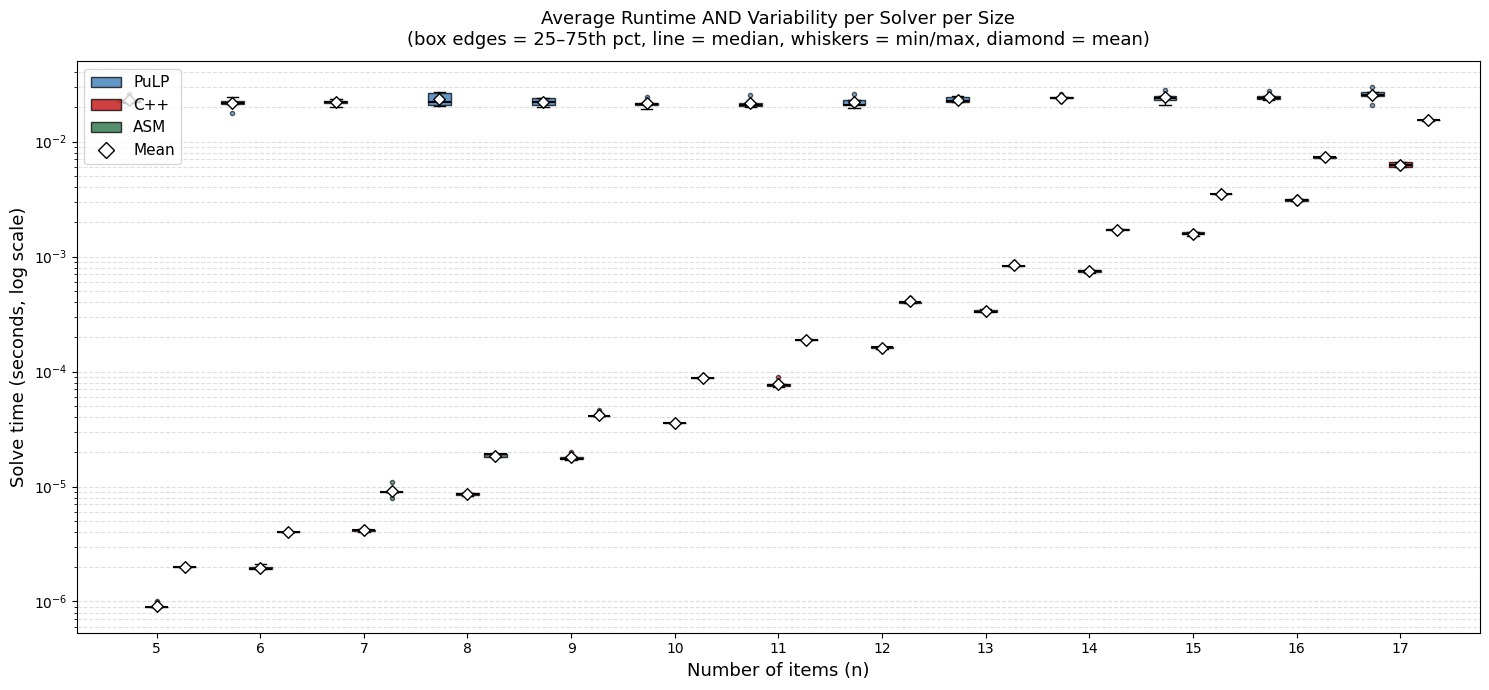

In [11]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(15, 7))

solvers = ["PuLP", "C++", "ASM"]
colors  = {"PuLP": "#2E75B6", "C++": "#C00000", "ASM": "#1D6A39"}
positions_per_size = [-0.27, 0.0, 0.27]
box_width = 0.22

for solver_idx, solver in enumerate(solvers):
    box_data = []
    box_positions = []
    means = []
    for size_idx, n in enumerate(df["n_items"]):
        trials = raw_df[(raw_df["n_items"] == n) & (raw_df["solver"] == solver)]["time"].values
        box_data.append(trials)
        box_positions.append(size_idx + positions_per_size[solver_idx])
        means.append(np.mean(trials))

    bp = ax.boxplot(
        box_data, positions=box_positions, widths=box_width,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, markerfacecolor=colors[solver], alpha=0.6),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(colors[solver])
        patch.set_alpha(0.75)
        patch.set_edgecolor("black")

    # Mean markers as diamonds
    ax.scatter(box_positions, means, marker="D", s=35,
               facecolor="white", edgecolor="black", zorder=5)

legend_patches = [Patch(facecolor=colors[s], edgecolor="black", alpha=0.75, label=s) for s in solvers]
legend_patches.append(plt.Line2D([0], [0], marker="D", color="w",
                                  markerfacecolor="white", markeredgecolor="black",
                                  markersize=8, label="Mean"))
ax.legend(handles=legend_patches, fontsize=11, loc="upper left")

ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["n_items"])
ax.set_xlabel("Number of items (n)", fontsize=13)
ax.set_ylabel("Solve time (seconds, log scale)", fontsize=13)
ax.set_title("Average Runtime AND Variability per Solver per Size\n(box edges = 25–75th pct, line = median, whiskers = min/max, diamond = mean)",
             fontsize=13, pad=12)
ax.set_yscale("log")
ax.grid(True, axis="y", which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("benchmark_3way_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Chart 5: Focused Box Plot at Largest n — Max / Mean / Min Annotated

For the largest problem size in our range (n=17), this box plot compares the three solvers side by side. Each box is annotated with its numeric **max**, **mean**, and **min**, matching the sketch in the instructor's notes.

C:\Users\magui\AppData\Local\Temp\ipykernel_19604\2699561201.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


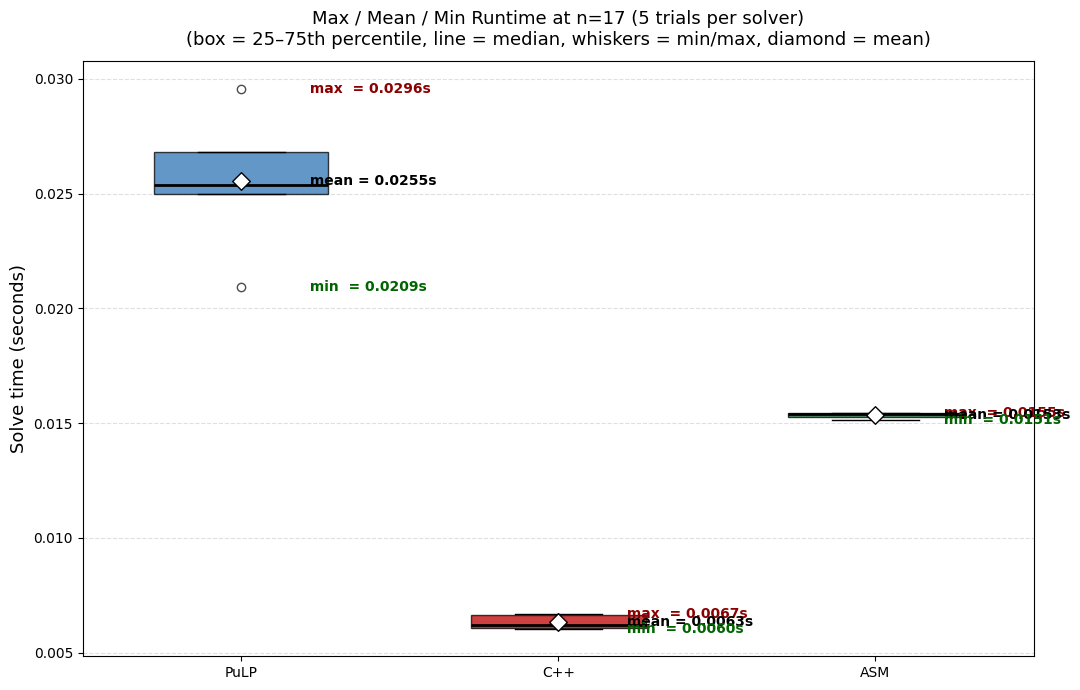

In [12]:
n_focus = int(df["n_items"].max())
focus = raw_df[raw_df["n_items"] == n_focus]

fig, ax = plt.subplots(figsize=(11, 7))

box_data = []
labels = []
face_colors = []
for solver in solvers:
    times = focus[focus["solver"] == solver]["time"].values
    box_data.append(times)
    labels.append(solver)
    face_colors.append(colors[solver])

bp = ax.boxplot(
    box_data, labels=labels, widths=0.55,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=6, alpha=0.7),
)
for patch, c in zip(bp["boxes"], face_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")

# Annotate mean, min, max for each solver
for i, solver in enumerate(solvers):
    times  = focus[focus["solver"] == solver]["time"].values
    mean_t = np.mean(times)
    min_t  = np.min(times)
    max_t  = np.max(times)

    ax.scatter(i + 1, mean_t, marker="D", s=80, color="white",
               edgecolor="black", zorder=5)
    ax.text(i + 1.20, max_t,  f" max  = {max_t:.4f}s", fontsize=10, va="center", color="darkred",   fontweight="bold")
    ax.text(i + 1.20, mean_t, f" mean = {mean_t:.4f}s", fontsize=10, va="center", color="black",     fontweight="bold")
    ax.text(i + 1.20, min_t,  f" min  = {min_t:.4f}s", fontsize=10, va="center", color="darkgreen", fontweight="bold")

ax.set_ylabel("Solve time (seconds)", fontsize=13)
ax.set_title(f"Max / Mean / Min Runtime at n={n_focus} (5 trials per solver)\n(box = 25–75th percentile, line = median, whiskers = min/max, diamond = mean)",
             fontsize=13, pad=12)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("benchmark_3way_boxplot_focus.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Discussion

### Headline result

Across the tested range (n=5 to n=17), **PuLP’s curve sits above both C++ and Assembly brute force** on every chart. The reason is structural: PuLP has a fixed library overhead of roughly 20 milliseconds per solve (loading the COIN-BC binary and constructing the LP model), while C++ and Assembly brute force only need microseconds at small n.

### Why this range matters

The choice of n=5 to n=17 isolates the **library-overhead regime**, where PuLP’s start-up cost dominates. At larger n (n=18+, not shown here), brute force time begins to exceed PuLP’s overhead and the lines would cross. This boundary is sometimes called the *crossover point* and is the natural transition between *overhead-dominated* and *computation-dominated* regimes.

### What the box plot adds

Chart 4 packs runtime and variability into one figure. Each box represents 5 trials at one problem size for one solver. Narrow boxes (C++, ASM) mean those solvers are very consistent because they do a deterministic number of operations. PuLP’s boxes are slightly wider because LP solver startup has small random variability.

### What this means for the capstone

The capstone’s central question is whether LLMs can generate correct, efficient low-level optimization code. This benchmark establishes baselines in the small-n regime:

- **Brute force in C++ and Assembly is fast** at small problem sizes because the iteration count is manageable
- **PuLP looks slow only because of library setup cost**, not because of bad algorithms
- The next iteration uses Claude CLI to generate branch-and-bound solvers in C++ and Python. The test is whether an LLM can produce code that matches PuLP’s quality at large n while being competitive at small n.

### Caveats

- **Small problem sizes only.** Beyond n=17 brute force becomes significant.
- **Single machine.** Times depend on CPU, cache, and background load.
- **5 trials per size.** A future run could use 10+ for tighter statistics.

### Next steps

1. Use Claude CLI to generate a branch-and-bound solver in C++ and Python.
2. Extend the benchmark range to n=20–40 where brute force breaks down.
3. Add OR-Library standard instances (Beasley 1990) for external validity.
